In [1]:
import time
import os
import random
import numpy as np     
import math

import matplotlib.pyplot as plt                                   
import autograd, autograd.core, autograd.extend, autograd.tracer  
import autograd.numpy as anp      
import scipy, scipy.ndimage, scipy.sparse, scipy.sparse.linalg 

from deap import base
from deap import creator
from deap import tools

import random
import matplotlib.pyplot as plt
import seaborn as sns

import sys
import numpy as np
from mpl_toolkits.mplot3d import Axes3D


import gym
from gymnasium import spaces

from stable_baselines3 import PPO, A2C
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.results_plotter import load_results, ts2xy
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common import results_plotter

from scipy.ndimage import rotate
from pathos.multiprocessing import ProcessingPool as Pool

In [2]:
sys.path.append('../../../../../ocean_intella/ocean_intella/pipelay_profile_optimization/')

In [3]:
import elitism

In [4]:
from scipy.spatial import ConvexHull

In [5]:
import networkx as nx

In [6]:
x0, y0 = 32, 32

# FEM Model

In [7]:
class ObjectView(object):
    def __init__(self, d): self.__dict__ = d
    
def get_args(normals, forces, density=1e-4):  # Manage the problem setup parameters
    width = normals.shape[0] - 1
    height = normals.shape[1] - 1
    fixdofs = np.flatnonzero(normals.ravel())
    alldofs = np.arange(2 * (width + 1) * (height + 1))
    freedofs = np.sort(list(set(alldofs) - set(fixdofs)))
    params = {
      # material properties
      'young': 1, 'young_min': 1e-9, 'poisson': 0.3, 'g': 0,
      # constraints
      'density': density, 'xmin': 0.001, 'xmax': 1.0,
      # input parameters
      'nelx': width, 'nely': height, 'mask': 1, 'penal': 3.0, 'filter_width': 1,
      'freedofs': freedofs, 'fixdofs': fixdofs, 'forces': forces.ravel(),
      # optimization parameters
      'opt_steps': 80, 'print_every': 10}
    return ObjectView(params)

def mbb_beam(width=y0, height=x0, density=1e-4, y=1, x=0, rd=-1):  # textbook beam example
    normals = np.zeros((width + 1, height + 1, 2))
    normals[0, 0, x] = 1
    normals[0, 0, y] = 1
    normals[0, -1, x] = 1
    normals[0, -1, y] = 1
    forces = np.zeros((width + 1, height + 1, 2))
    forces[-1, rd, y] = -1
    return normals, forces, density

In [8]:
def young_modulus(x, e_0, e_min, p=3):
    return e_min + x ** p * (e_0 - e_min)

def physical_density(x, args, volume_contraint=False, use_filter=True):
    x = args.mask * x.reshape(args.nely, args.nelx)  # reshape from 1D to 2D
    return gaussian_filter(x, args.filter_width) if use_filter else x  # maybe filter

def mean_density(x, args, volume_contraint=False, use_filter=True):
    return anp.mean(physical_density(x, args, volume_contraint, use_filter)) / anp.mean(args.mask)

In [9]:
def objective(x, args, volume_contraint=False, use_filter=True):
    kwargs = dict(penal=args.penal, e_min=args.young_min, e_0=args.young)
    x_phys = physical_density(x, args, volume_contraint=volume_contraint, use_filter=use_filter)
    ke     = get_stiffness_matrix(args.young, args.poisson)  # stiffness matrix
    u      = displace(x_phys, ke, args.forces, args.freedofs, args.fixdofs, **kwargs)
    c      = compliance(x_phys, u, ke, **kwargs)
    return c

In [10]:
@autograd.extend.primitive
def gaussian_filter(x, width): # 2D gaussian blur/filter
    return scipy.ndimage.gaussian_filter(x, width, mode='reflect')

def _gaussian_filter_vjp(ans, x, width): # gives the gradient of orig. function w.r.t. x
    del ans, x  # unused
    return lambda g: gaussian_filter(g, width)
autograd.extend.defvjp(gaussian_filter, _gaussian_filter_vjp)

In [11]:
def compliance(x_phys, u, ke, *, penal=3, e_min=1e-9, e_0=1):
    nely, nelx = x_phys.shape
    ely, elx = anp.meshgrid(range(nely), range(nelx))  # x, y coords for the index map

    n1 = (nely+1)*(elx+0) + (ely+0)  # nodes
    n2 = (nely+1)*(elx+1) + (ely+0)
    n3 = (nely+1)*(elx+1) + (ely+1)
    n4 = (nely+1)*(elx+0) + (ely+1)
    all_ixs = anp.array([2*n1, 2*n1+1, 2*n2, 2*n2+1, 2*n3, 2*n3+1, 2*n4, 2*n4+1])
    u_selected = u[all_ixs]  # select from u matrix

    ke_u = anp.einsum('ij,jkl->ikl', ke, u_selected)  # compute x^penal * U.T @ ke @ U
    ce = anp.einsum('ijk,ijk->jk', u_selected, ke_u)
    C = young_modulus(x_phys, e_0, e_min, p=penal) * ce.T
    return anp.sum(C)

def get_stiffness_matrix(e, nu):  # e=young's modulus, nu=poisson coefficient
    k = anp.array([1/2-nu/6, 1/8+nu/8, -1/4-nu/12, -1/8+3*nu/8,
                -1/4+nu/12, -1/8-nu/8, nu/6, 1/8-3*nu/8])
    return e/(1-nu**2)*anp.array([[k[0], k[1], k[2], k[3], k[4], k[5], k[6], k[7]],
                               [k[1], k[0], k[7], k[6], k[5], k[4], k[3], k[2]],
                               [k[2], k[7], k[0], k[5], k[6], k[3], k[4], k[1]],
                               [k[3], k[6], k[5], k[0], k[7], k[2], k[1], k[4]],
                               [k[4], k[5], k[6], k[7], k[0], k[1], k[2], k[3]],
                               [k[5], k[4], k[3], k[2], k[1], k[0], k[7], k[6]],
                               [k[6], k[3], k[4], k[1], k[2], k[7], k[0], k[5]],
                               [k[7], k[2], k[1], k[4], k[3], k[6], k[5], k[0]]])

In [12]:
def get_k(stiffness, ke):
    # Constructs sparse stiffness matrix k (used in the displace fn)
    # First, get position of the nodes of each element in the stiffness matrix
    nely, nelx = stiffness.shape
    ely, elx = anp.meshgrid(range(nely), range(nelx))  # x, y coords
    ely, elx = ely.reshape(-1, 1), elx.reshape(-1, 1)

    n1 = (nely+1)*(elx+0) + (ely+0)
    n2 = (nely+1)*(elx+1) + (ely+0)
    n3 = (nely+1)*(elx+1) + (ely+1)
    n4 = (nely+1)*(elx+0) + (ely+1)
    edof = anp.array([2*n1, 2*n1+1, 2*n2, 2*n2+1, 2*n3, 2*n3+1, 2*n4, 2*n4+1])
    edof = edof.T[0]
    x_list = anp.repeat(edof, 8)  # flat list pointer of each node in an element
    y_list = anp.tile(edof, 8).flatten()  # flat list pointer of each node in elem

    # make the global stiffness matrix K
    kd = stiffness.T.reshape(nelx*nely, 1, 1)
    value_list = (kd * anp.tile(ke, kd.shape)).flatten()
    return value_list, y_list, x_list

def displace(x_phys, ke, forces, freedofs, fixdofs, *, penal=3, e_min=1e-9, e_0=1):
    # Displaces the load x using finite element techniques (solve_coo=most of runtime)
    stiffness = young_modulus(x_phys, e_0, e_min, p=penal)
    k_entries, k_ylist, k_xlist = get_k(stiffness, ke)

    index_map, keep, indices = _get_dof_indices(freedofs, fixdofs, k_ylist, k_xlist)

    u_nonzero = solve_coo(k_entries[keep], indices, forces[freedofs], sym_pos=True)
    u_values = anp.concatenate([u_nonzero, anp.zeros(len(fixdofs))])
    return u_values[index_map]

In [13]:
def _get_dof_indices(freedofs, fixdofs, k_xlist, k_ylist):
    index_map = inverse_permutation(anp.concatenate([freedofs, fixdofs]))
    keep = anp.isin(k_xlist, freedofs) & anp.isin(k_ylist, freedofs)
    # Now we index an indexing array that is being indexed by the indices of k
    i = index_map[k_ylist][keep]
    j = index_map[k_xlist][keep]
    return index_map, keep, anp.stack([i, j])

def inverse_permutation(indices):  # reverses an index operation
    inverse_perm = np.zeros(len(indices), dtype=anp.int64)
    inverse_perm[indices] = np.arange(len(indices), dtype=anp.int64)
    return inverse_perm

In [14]:
def _get_solver(a_entries, a_indices, size, sym_pos):
    # a is (usu.) symmetric positive; could solve 2x faster w/sksparse.cholmod.cholesky(a).solve_A
    a = scipy.sparse.coo_matrix((a_entries, a_indices), shape=(size,)*2).tocsc()
    return scipy.sparse.linalg.splu(a).solve

@autograd.primitive
def solve_coo(a_entries, a_indices, b, sym_pos=False):
    solver = _get_solver(a_entries, a_indices, b.size, sym_pos)
    return solver(b)

def grad_solve_coo_entries(ans, a_entries, a_indices, b, sym_pos=False):
    def jvp(grad_ans):
        lambda_ = solve_coo(a_entries, a_indices if sym_pos else a_indices[::-1],
                            grad_ans, sym_pos)
        i, j = a_indices
        return -lambda_[i] * ans[j]
    return jvp

autograd.extend.defvjp(solve_coo, grad_solve_coo_entries,
                       lambda: print('err: gradient undefined'),
                       lambda: print('err: gradient not implemented'))

In [15]:
def fast_stopt(args, x):

    reshape = lambda x: x.reshape(args.nely, args.nelx)
    objective_fn = lambda x: objective(reshape(x), args)
#     constraint = lambda params: mean_density(reshape(params), args) - args.density
    constraint = lambda params: mean_density(reshape(params), args) 
    value = objective_fn(x)
    const = constraint(x)
    return value, const

In [16]:
def draw(X):  
    plt.figure(dpi=50) 
    print('\nFinal Cantilever beam design:')
    plt.imshow(X) 
    plt.show()

# Genetic Modelling

In [17]:
# Genetic Algorithm constants:
POPULATION_SIZE = 300
P_CROSSOVER = 0.9  # probability for crossover
P_MUTATION = 0.1   # probability for mutating an individual
MAX_GENERATIONS = 2000
HALL_OF_FAME_SIZE = 30

In [18]:
PENALTY_VALUE = 1000.0    

In [19]:
# set the random seed:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

In [20]:
toolbox = base.Toolbox()

In [21]:
# define a single objective, minimizing fitness strategy:
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))

In [22]:
# create the Individual class based on list:
creator.create("Individual", list, fitness=creator.FitnessMin)

In [23]:
# create an operator that randomly returns 0 or 1:
toolbox.register("zeroOrOne", random.randint, 0, 1)

In [24]:
# create the individual operator to fill up an Individual instance:
toolbox.register("individualCreator", 
                 tools.initRepeat,
                 creator.Individual,
                 toolbox.zeroOrOne, 
                 x0*y0+4)

In [25]:
# create the population operator to generate a list of individuals:
toolbox.register("populationCreator", 
                 tools.initRepeat, 
                 list, 
                 toolbox.individualCreator)

In [26]:
# convert a binary list to decimal
def binatodeci(binary):
    return sum(val*(2**idx) for idx, val in enumerate(reversed(binary)))

In [27]:
class Prev:
    def __init__(self):
        self.prev = 100

In [28]:
T=Prev()

In [29]:
# fitness calculation
def staticFEM(individual):
    
    args = get_args(*mbb_beam(rd=-1))
    
    x = np.array([t if t==1 else 1e-4 for t in individual[:-4]]) 
    
    
    try:
        if np.sum(x)/(x0*y0) > 0.55:
            tmp, const = fast_stopt(args, x)
            T.prev=tmp
            if const>(55+binatodeci(individual[-4:]))/100:
                return PENALTY_VALUE, 
        else:
            return T.prev,
    except:
        return PENALTY_VALUE, 
    
    
    return tmp,  # return a tuple

In [30]:
toolbox.register("evaluate", staticFEM)
pool = Pool(8)
toolbox.register("map", pool.map)

# genetic operators:
toolbox.register("select", tools.selTournament, tournsize=2)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=1.0/(x0*y0+4))

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


In [31]:
# Genetic Algorithm flow:
def main():

    # create initial population (generation 0):
    population = toolbox.populationCreator(n=POPULATION_SIZE)

    # prepare the statistics object:
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("min", np.min)
    stats.register("avg", np.mean)

    # define the hall-of-fame object:
    hof = tools.HallOfFame(HALL_OF_FAME_SIZE)

    # perform the Genetic Algorithm flow with hof feature added:
    population, logbook = elitism.eaSimpleWithElitism(population, toolbox, cxpb=P_CROSSOVER, mutpb=P_MUTATION,
                                              ngen=MAX_GENERATIONS, stats=stats, halloffame=hof, verbose=True)

    # print best solution found:
    best = hof.items[0]
    print("-- Best Individual = ", best)
    print("-- Best Fitness = ", best.fitness.values[0])
    print()
    
    x = np.array(best[:-4]).astype(np.float64).reshape(x0,y0)
    
    args = get_args(*mbb_beam(rd=-1))
    print(fast_stopt(args, x))
    
    draw(x)
    

    # extract statistics:
    minFitnessValues, meanFitnessValues = logbook.select("min", "avg")

    # plot statistics:
    sns.set_style("whitegrid")
    plt.plot(minFitnessValues, color='red')
    plt.plot(meanFitnessValues, color='green')
  
    plt.xlabel('Generation')
    plt.ylabel('Min / Average Fitness')
    plt.title('Min and Average fitness over Generations')
    plt.show()    
    return x

gen	nevals	min	avg
0  	300   	100	100
1  	249   	100	100
2  	247   	100	100
3  	248   	100	100
4  	239   	100	100
5  	247   	100	100
6  	234   	100	100
7  	243   	100	100
8  	239   	100	100
9  	237   	100	100
10 	254   	100	100
11 	245   	100	100
12 	240   	100	100
13 	238   	100	100
14 	240   	100	100
15 	247   	100	298.673
16 	249   	100	1160.65
17 	259   	100	1260.05
18 	257   	100	1078.6 
19 	250   	100	1079.63
20 	244   	100	1029.94
21 	247   	100	1178.91
22 	257   	100	802.767
23 	250   	100	571.178
24 	236   	100	2465.6 
25 	241   	100	3791.04
26 	251   	100	3285.22
27 	250   	100	3187.37
28 	258   	100	3350.77
29 	239   	100	3775.43
30 	253   	100	3725.59
31 	241   	100	3740.67
32 	250   	100	3775.57
33 	242   	100	3791.9 
34 	251   	100	3791.85
35 	242   	100	3220.39
36 	244   	100	2990.61
37 	257   	100	4233.28
38 	241   	100	3774.17
39 	253   	100	3775.63
40 	254   	100	3792.06
41 	245   	100	3758.67
42 	252   	100	3708.89
43 	249   	100	3659.53
44 	243   	100	3708.68
45 	23

358	250   	100	163.849
359	250   	100	162.997
360	251   	100	162.974
361	247   	100	162.387
362	250   	100	163.859
363	251   	100	163.585
364	247   	100	162.924
365	248   	100	163.142
366	257   	100	157.711
367	246   	100	162.696
368	247   	100	161.29 
369	239   	100	165.021
370	244   	100	164.281
371	239   	100	158.77 
372	248   	100	159.668
373	245   	100	161.842
374	255   	100	162.345
375	245   	100	162.038
376	249   	100	163.15 
377	240   	100	165.674
378	251   	100	163.552
379	234   	100	159.427
380	245   	100	158.341
381	236   	100	157.763
382	236   	100	371.832
383	245   	100	678.252
384	246   	100	694.281
385	259   	100	592.314
386	250   	100	676.794
387	244   	100	677.103
388	251   	100	676.822
389	257   	100	746.309
390	237   	100	755.58 
391	240   	100	2586.09
392	246   	100	2721.05
393	249   	100	2721.08
394	240   	100	2226.78
395	241   	100	2739.85
396	238   	100	2752.03
397	243   	100	2588.59
398	253   	100	2727.06
399	244   	100	2786.85
400	242   	100	2387.02
401	256   	

680	226   	49.1385	51.8514
681	233   	48.9677	51.2398
682	233   	46.9521	50.6138
683	258   	46.8755	49.9604
684	250   	46.2617	49.3005
685	248   	45.806 	48.7805
686	240   	45.3161	48.0722
687	250   	45.3161	47.3954
688	242   	45.3161	46.7281
689	251   	45.0269	46.2648
690	242   	44.7404	45.9435
691	243   	44.7404	45.6698
692	246   	44.2779	45.4155
693	255   	44.112 	48.3534
694	245   	44.0361	44.9412
695	244   	43.74  	44.6988
696	258   	43.3476	44.4835
697	252   	42.8778	44.2401
698	246   	42.4969	44.0294
699	239   	42.4969	43.7736
700	250   	42.191 	43.4377
701	247   	42.1291	43.118 
702	242   	41.802 	42.8847
703	239   	41.5708	42.6083
704	249   	41.4031	42.4157
705	244   	41.3396	42.234 
706	251   	41.2863	42.0366
707	255   	40.9557	41.8592
708	253   	40.8134	41.677 
709	250   	40.773 	41.526 
710	248   	40.6719	41.339 
711	247   	40.4201	41.1807
712	239   	39.9799	41.0231
713	238   	39.9799	40.9046
714	241   	39.5956	40.7029
715	245   	39.5956	40.4944
716	233   	39.1385	40.2901
7

984	244   	28.2904	167.644
985	245   	28.2776	187.066
986	249   	28.2776	167.624
987	252   	28.2489	161.138
988	239   	28.2387	167.606
989	251   	28.2387	196.765
990	248   	28.2289	154.654
991	241   	28.2098	154.627
992	239   	28.2009	170.804
993	245   	28.2009	167.565
994	239   	28.1492	135.163
995	249   	28.1492	177.25 
996	243   	28.1492	128.653
997	232   	28.1422	128.649
998	245   	28.1422	154.584
999	239   	28.1397	122.146
1000	253   	28.0954	144.813
1001	257   	28.0699	173.966
1002	238   	28.0699	151.279
1003	244   	28.0385	109.147
1004	243   	28.0385	138.318
1005	240   	28.0019	147.987
1006	242   	28.0019	157.706
1007	251   	27.967 	151.201
1008	236   	27.967 	138.24 
1009	245   	27.957 	170.612
1010	234   	27.9424	160.882
1011	238   	27.9424	170.62 
1012	251   	27.8723	196.511
1013	249   	27.8723	183.532
1014	240   	27.8622	134.925
1015	238   	27.8524	157.587
1016	258   	27.8004	141.371
1017	237   	27.8004	154.324
1018	245   	27.7858	199.688
1019	256   	27.7858	186.715
1020	250

1278	241   	23.932 	128.104
1279	250   	23.932 	144.364
1280	243   	23.932 	163.879
1281	251   	23.9125	167.13 
1282	239   	23.9125	134.601
1283	251   	23.9008	150.853
1284	243   	23.9008	137.83 
1285	255   	23.9008	118.336
1286	254   	23.8792	115.047
1287	244   	23.8692	118.284
1288	247   	23.8574	111.778
1289	249   	23.8574	137.858
1290	259   	23.8537	124.775
1291	250   	23.8537	141.037
1292	226   	23.8274	131.273
1293	251   	23.8274	124.76 
1294	242   	23.8274	121.492
1295	243   	23.8274	127.993
1296	238   	23.8158	147.512
1297	242   	23.7849	127.982
1298	256   	23.7849	127.991
1299	256   	23.7849	111.741
1300	249   	23.7792	128.057
1301	235   	23.7621	95.4149
1302	247   	23.7621	124.696
1303	244   	23.7621	114.925
1304	240   	23.7478	144.205
1305	244   	23.7478	85.6271
1306	238   	23.7478	127.927
1307	244   	23.7478	101.889
1308	250   	23.7478	118.152
1309	238   	23.7478	127.906
1310	240   	23.7478	121.403
1311	248   	23.7388	118.139
1312	251   	23.7388	98.646 
1313	240   	23.7388	

1571	240   	22.8279	140.11 
1572	231   	22.8203	133.607
1573	241   	22.8203	127.079
1574	240   	22.8203	94.5072
1575	249   	22.8203	123.818
1576	244   	22.8203	114.048
1577	232   	22.8203	123.816
1578	245   	22.8203	156.397
1579	245   	22.8203	156.387
1580	244   	22.8203	136.85 
1581	248   	22.8203	127.074
1582	244   	22.8158	188.958
1583	250   	22.8157	172.674
1584	240   	22.8157	175.956
1585	250   	22.8146	146.614
1586	240   	22.8146	146.611
1587	249   	22.8128	169.414
1588	243   	22.8128	140.093
1589	250   	22.8057	159.636
1590	247   	22.8057	133.576
1591	244   	22.8035	143.355
1592	241   	22.8017	133.571
1593	244   	22.8017	97.7666
1594	245   	22.8017	104.25 
1595	242   	22.8017	120.536
1596	251   	22.8017	114.029
1597	243   	22.8017	133.581
1598	247   	22.7953	104.265
1599	241   	22.7953	101.017
1600	243   	22.7898	120.53 
1601	243   	22.7898	97.7593
1602	245   	22.786 	81.4441
1603	243   	22.786 	97.7264
1604	255   	22.78  	133.562
1605	246   	22.7568	166.132
1606	246   	22.7568	

1864	243   	22.4276	74.5775
1865	247   	22.4276	110.423
1866	246   	22.424 	120.195
1867	245   	22.424 	126.714
1868	259   	22.4191	133.234
1869	251   	22.4191	120.195
1870	248   	22.4191	143.003
1871	252   	22.4191	149.521
1872	238   	22.4191	107.166
1873	246   	22.4189	136.486
1874	238   	22.4189	103.898
1875	243   	22.4189	110.416
1876	238   	22.4189	136.486
1877	254   	22.4189	139.742
1878	251   	22.4189	126.706
1879	241   	22.4189	123.446
1880	250   	22.4184	142.998
1881	254   	22.4109	126.706
1882	253   	22.4109	126.712
1883	255   	22.4109	97.3774
1884	251   	22.4109	116.929
1885	235   	22.4062	90.8544
1886	236   	22.4062	81.099 
1887	245   	22.4062	81.0875
1888	248   	22.4062	113.699
1889	247   	22.4062	103.89 
1890	253   	22.4062	81.0795
1891	264   	22.4062	103.887
1892	247   	22.4062	94.1111
1893	244   	22.4062	126.704
1894	252   	22.4062	146.256
1895	243   	22.4062	107.161
1896	256   	22.4062	113.678
1897	246   	22.4062	113.662
1898	251   	22.4062	113.693
1899	238   	22.4062	

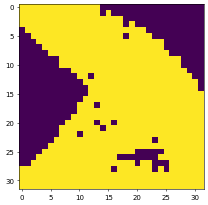

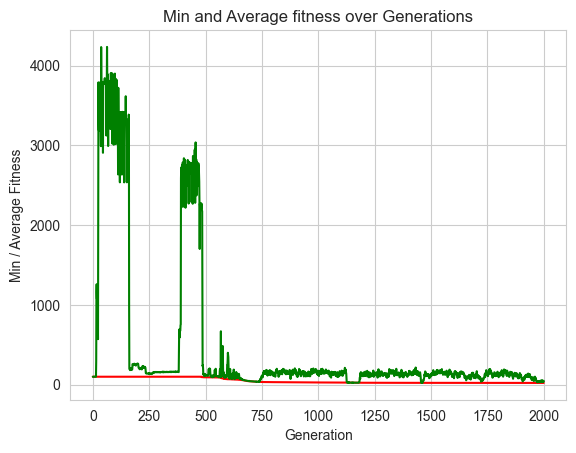

In [32]:
if __name__ == "__main__":
    start = time.time()
    top_ = main()
    end = time.time()  
    pool.close()   
    pool.join()

In [33]:
print('Total time taken: {} min'.format((end - start)/60))

Total time taken: 16.80402938524882 min


In [34]:
class Model:
    def __init__(self, x):
        self.flag_ = True
#         self.flag_ = False
        self.n, self.m = x.shape
        self.actions_dic={} 
    
        k=0
        for i in range(self.n):
            for j in range(self.m):
                count = 0
                if x[i][j]==1:
                    
                
                    if 0<=i+1<self.n and x[i+1][j]==1:
                        count+=1
                    if 0<=i-1<self.n and x[i-1][j]==1:
                        count+=1 
                    if 0<=j+1<self.m and x[i][j+1]==1:
                        count+=1
                    if 0<=j-1<self.m and x[i][j-1]==1:
                        count+=1   
#                     if i==0 or i== self.n-1 or j==0 or j==self.m-1:
#                         count+=1
                
                
                    if count<4:
                        self.actions_dic[k]=(i,j)
                        k+=1
                        
                elif  x[i][j]==0:
                    x[i][j]+=1e-4
        
    def action_space_(self, action, X):
        x,y=self.actions_dic[action]
        X[x][y]=1e-4
        
    def draw(self,X):  
        plt.figure(dpi=50) 
        print('\nFinal Cantilever beam design:')
        plt.imshow(X) 
        plt.show()

In [35]:
def calculate_smoothness_metric(binary_matrix):
    """
    Calculates a smoothness metric for a 2D binary matrix.
    Lower values indicate greater smoothness. A value of 0 means 
    the image is perfectly uniform or has only linear transitions.

    The metric is the sum of differences between a pixel and its
    right and bottom neighbors, effectively counting vertical and
    horizontal edges.

    Args:
        binary_matrix (list of lists or numpy array): A 2D matrix 
                                                     with values 0 or 1.

    Returns:
        int: The total count of horizontal and vertical transitions.
    """
    # Convert to a numpy array for efficient processing
    matrix = np.array(binary_matrix, dtype=int)
    h, w = matrix.shape
    
    # Calculate absolute differences for horizontal transitions
    # We slice the matrix to compare each element with its right neighbor
    horizontal_diffs = np.abs(matrix[:, :w-1] - matrix[:, 1:])
    
    # Calculate absolute differences for vertical transitions
    # We slice the matrix to compare each element with its bottom neighbor
    vertical_diffs = np.abs(matrix[:h-1, :] - matrix[1:, :])
    
    # The sum of these differences gives the total number of transitions (edges)
    total_transitions = np.sum(horizontal_diffs) + np.sum(vertical_diffs)
    
    return int(total_transitions)

In [36]:
def count_islands_dfs(grid):
    """
    Calculates the number of islands in a 2D binary grid using Depth First Search (DFS).

    An island is formed by connected 1's (horizontally/vertically adjacent).
    
    Args:
        grid (list of lists): A 2D matrix with values 0 or 1.

    Returns:
        int: The total number of islands found.
    """
#     if not grid or not grid[0]:
#         return 0
    
    rows = len(grid)
    cols = len(grid[0])
    visited = set()
    island_count = 0

    def dfs(r, c):
        """Helper function to traverse and mark a single island as visited."""
        # Check boundary conditions and if the cell has already been visited or is water (0)
        if r < 0 or r >= rows or c < 0 or c >= cols or grid[r][c] == 0 or (r, c) in visited:
            return
        
        visited.add((r, c))
        
        # Recursively visit all adjacent cells (up, down, left, right)
        dfs(r + 1, c) # Down
        dfs(r - 1, c) # Up
        dfs(r, c + 1) # Right
        dfs(r, c - 1) # Left

    # Iterate through every cell in the grid
    for r in range(rows):
        for c in range(cols):
            # If we find land (1) that hasn't been visited yet, 
            # it means we've found the start of a new island.
            if grid[r][c] == 1 and (r, c) not in visited:
                island_count += 1
                # Start DFS from this point to mark all parts of this island
                dfs(r, c)
                
    return island_count

In [37]:
class CantileverEnv(gym.Env):
    
    metadata = {"render.modes": ["human"]}

    def __init__(self,topology, normalized_image: bool = False):
        super().__init__()
        
        
        self.rd=0
        self.args = get_args(*mbb_beam(rd=self.rd))
        
#         DIM=self.args.nelx*self.args.nely

        self.topology=topology.copy()
        self.x = self.topology.copy()

        self.M=Model(self.x)

        N_DISCRETE_ACTIONS=len(self.M.actions_dic)
        
        self.action_space = spaces.Discrete(N_DISCRETE_ACTIONS)
        self.observation_space = spaces.Box(low=0,
                                            high=255,
                                            shape=(self.args.nely, self.args.nelx, 1),
                                            dtype=np.float64)
        
        
        
        self.reward=0
        self.step_=0
        self.needs_reset = True
        
    def step(self, action):
        
        self.args = get_args(*mbb_beam(rd=self.rd))

        self.M.action_space_(action, self.x)

        self.step_+=1
               
        done=False
                  
        if self.step_>self.M.n*self.M.m:
            done=True
            
        const1=np.sum(self.x)/(x0*y0)   
        
        if const1>0.7:
#             self.reward-=1
            done=True
            
        if self.needs_reset:
            raise RuntimeError("Tried to step environment that needs reset")
            
        if done:
            tmp, const = fast_stopt(self.args, self.x)
            self.reward=1/tmp+1/calculate_smoothness_metric(self.x.reshape(y0,x0))
            if count_islands_dfs(self.x)==1:
                self.reward*=10
            self.needs_reset = True

        return self.x.reshape(x0,y0,1), self.reward, done, False, {}

    def reset(self, seed=0):
        
        if not self.M.flag_:
            self.rd=random.choice([0,2,-2])
        else:
            self.rd=-1
           
        self.x = self.topology.copy()

        self.reward=0
        self.needs_reset = False
        self.step_=0

        return self.x.reshape(x0,y0,1), {}

    def render(self, mode="human"):
        self.M.draw(self.x)    

    def close(self):
        pass

In [38]:
class SaveOnBestTrainingRewardCallback(BaseCallback):
    """
    Callback for saving a model (the check is done every ``check_freq`` steps)
    based on the training reward (in practice, we recommend using ``EvalCallback``).

    :param check_freq: (int)
    :param log_dir: (str) Path to the folder where the model will be saved.
      It must contains the file created by the ``Monitor`` wrapper.
    :param verbose: (int)
    """

    def __init__(self, check_freq: int, log_dir: str, verbose=1):
        super().__init__(verbose)
        self.check_freq = check_freq
        self.log_dir = log_dir
        self.save_path = os.path.join(log_dir, "best_model")
        self.best_mean_reward = -np.inf

    def _init_callback(self) -> None:
        # Create folder if needed
        if self.save_path is not None:
            os.makedirs(self.save_path, exist_ok=True)

    def _on_step(self) -> bool:
        if self.n_calls % self.check_freq == 0:

            # Retrieve training reward
            x, y = ts2xy(load_results(self.log_dir), "timesteps")
            if len(x) > 0:
                # Mean training reward over the last 100 episodes
                mean_reward = np.mean(y[-100:])
                if self.verbose > 0:
                    print(f"Num timesteps: {self.num_timesteps}")
                    print(
                        f"Best mean reward: {self.best_mean_reward:.2f} - Last mean reward per episode: {mean_reward:.2f}"
                    )

                # New best model, you could save the agent here
                if mean_reward > self.best_mean_reward:
                    self.best_mean_reward = mean_reward
                    # Example for saving best model
                    if self.verbose > 0:
                        print(f"Saving new best model to {self.save_path}.zip")
                    self.model.save(self.save_path)

        return True

In [39]:
ts=5e6

In [40]:
# Create log dir
log_dir = "/tmp/gym_gen_1_2bdkjdn4289u2/"
os.makedirs(log_dir, exist_ok=True)

# Create and wrap the environment
env = CantileverEnv(topology=top_)
# Logs will be saved in log_dir/monitor.csv
env = Monitor(env, log_dir)
check_env(env)

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/stable_baselines3/common/env_checker.py:54: UserWarning: It seems that your observation  is an image but its `dtype` is (float64) whereas it has to be `np.uint8`. If your observation is not an image, we recommend you to flatten the observation to have only a 1D vector
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/stable_baselines3/common/env_checker.py:75: UserWarning: The minimal resolution for an image is 36x36 for the default `CnnPolicy`. You might need to use a custom features extractor cf. https://stable-baselines3.readthedocs.io/en/master/guide/custom_policy.html
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.render_mode to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.render_mode` for 

In [41]:
callback = SaveOnBestTrainingRewardCallback(check_freq = 100_000, log_dir = log_dir)

In [42]:
start = time.time()
model = PPO("MlpPolicy", env).learn(total_timesteps=ts, callback=callback)
end = time.time()   

Num timesteps: 100000
Best mean reward: -inf - Last mean reward per episode: 0.05
Saving new best model to /tmp/gym_gen_1_2bdkjdn4289u2/best_model.zip
Num timesteps: 200000
Best mean reward: 0.05 - Last mean reward per episode: 0.22
Saving new best model to /tmp/gym_gen_1_2bdkjdn4289u2/best_model.zip
Num timesteps: 300000
Best mean reward: 0.22 - Last mean reward per episode: 0.30
Saving new best model to /tmp/gym_gen_1_2bdkjdn4289u2/best_model.zip
Num timesteps: 400000
Best mean reward: 0.30 - Last mean reward per episode: 0.40
Saving new best model to /tmp/gym_gen_1_2bdkjdn4289u2/best_model.zip
Num timesteps: 500000
Best mean reward: 0.40 - Last mean reward per episode: 0.39
Num timesteps: 600000
Best mean reward: 0.40 - Last mean reward per episode: 0.38
Num timesteps: 700000
Best mean reward: 0.40 - Last mean reward per episode: 0.38
Num timesteps: 800000
Best mean reward: 0.40 - Last mean reward per episode: 0.40
Saving new best model to /tmp/gym_gen_1_2bdkjdn4289u2/best_model.zip

In [43]:
print('Total time taken: {} min'.format((end - start)/60))

Total time taken: 69.09738393624623 min


### Inference

In [44]:
# env.M.flag_=True
env.M.flag_=False
obs=env.reset()
obs=obs[0]

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.M to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.M` for environment variables or `env.get_wrapper_attr('M')` that will search the reminding wrappers.
  logger.warn(


In [45]:
i=0
while i<2000:
    action, _states = model.predict(obs)
    obs, rewards, dones, _ , info = env.step(int(action))
    if dones: 
        break
    i+=1

In [46]:
print(i)

1024


In [47]:
fast_stopt(env.args, env.x)

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.args to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.args` for environment variables or `env.get_wrapper_attr('args')` that will search the reminding wrappers.
  logger.warn(
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.x to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.x` for environment variables or `env.get_wrapper_attr('x')` that will search the reminding wrappers.
  logger.warn(


(3552889582.2298417, 0.6767600585937501)


Final Cantilever beam design:


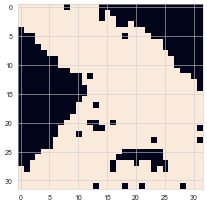

In [48]:
env.render()

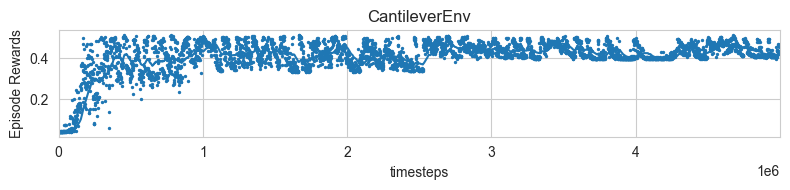

In [49]:
results_plotter.plot_results([log_dir], ts, results_plotter.X_TIMESTEPS, "CantileverEnv")

In [183]:
obs=env.reset()
obs=obs[0]

In [184]:
# Load the agent
model_best = PPO.load(log_dir + "best_model.zip", env=env)

In [185]:
i=0
while i<2000:
    action, _states = model_best.predict(obs)
    
    obs, rewards, dones, _ , info = env.step(int(action))
    if dones:
        break
    i+=1

In [186]:
i

1024


Final Cantilever beam design:


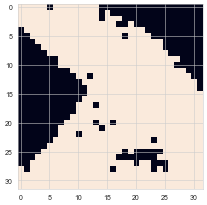

In [187]:
env.render()

In [188]:
# https://stable-baselines3.readthedocs.io/en/master/guide/save_format.html

In [189]:
fast_stopt(env.args, env.x)

(20.70759249281561, 0.6933599609375001)